# Inverted Pendulum in MuJoCo with Cascade PID

Notebook này mô hình hóa đúng bài toán cart-pole 2D trong [inverted_pendulum_v03.xml](inverted_pendulum_v03/inverted_pendulum_v03.xml):
- xe trượt theo trục `x`
- con lắc quay quanh khớp `hinge`
- điều khiển là lực ngang `F = data.ctrl[0]`

Mục tiêu là đưa mô hình Python truyền thống của bạn vào notebook theo cách dễ đọc, dễ chỉnh gain và dễ quan sát video/đồ thị.

## Theory

### 1. Trạng thái và điều khiển

Mô hình dùng 4 trạng thái chuẩn của con lắc ngược trên xe:
- `x`: vị trí xe
- `x_dot`: vận tốc xe
- `theta`: góc con lắc
- `theta_dot`: vận tốc góc

Đầu vào điều khiển là:
- `F`: lực ngang tác dụng lên khớp trượt của xe

Trong XML này, actuator `force` gắn trực tiếp vào joint `slider`, nên `data.ctrl[0]` chính là lệnh lực theo đơn vị Newton.

### 2. Cascade PID

Ta dùng hai vòng PID nối tầng:
1. Vòng ngoài giữ vị trí xe tại `x = 0`
2. Vòng trong giữ con lắc tại `theta = 0`

Sơ đồ khái niệm:

```text
x_ref = 0 --> PID_position --> theta_ref --> PID_angle --> F
```

Ý nghĩa:
- Nếu xe lệch khỏi gốc, PID vị trí không đẩy lực trực tiếp mà sinh ra một góc nghiêng mục tiêu `theta_ref`
- PID góc sẽ tạo lực `F` để kéo con lắc về `theta_ref`
- Với cách này, vòng trong nhanh hơn vòng ngoài và hệ thường dễ tuning hơn một PID duy nhất

### 3. Quy ước dấu

Trong notebook này ta giữ đúng logic từ script của bạn:
- khi `theta > 0`, xe cần sinh lực đúng chiều để đỡ con lắc
- vì PID dùng công thức `error = setpoint - measurement`, nên gain của vòng góc được chọn dấu âm để đầu ra có chiều mong muốn

### 4. Disturbance test

Để kiểm tra độ bền vững, mô phỏng sẽ có thêm các xung lực ngoài trong một số khoảng thời gian ngắn.
Điều này giúp nhìn rõ hệ có phục hồi lại trạng thái cân bằng hay không.

In [ ]:
import os
os.environ['MUJOCO_GL'] = 'egl'

import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import mediapy as media
import mujoco

""

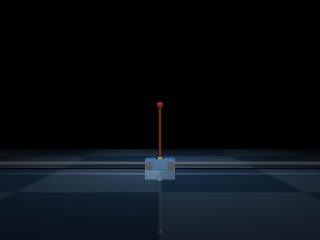

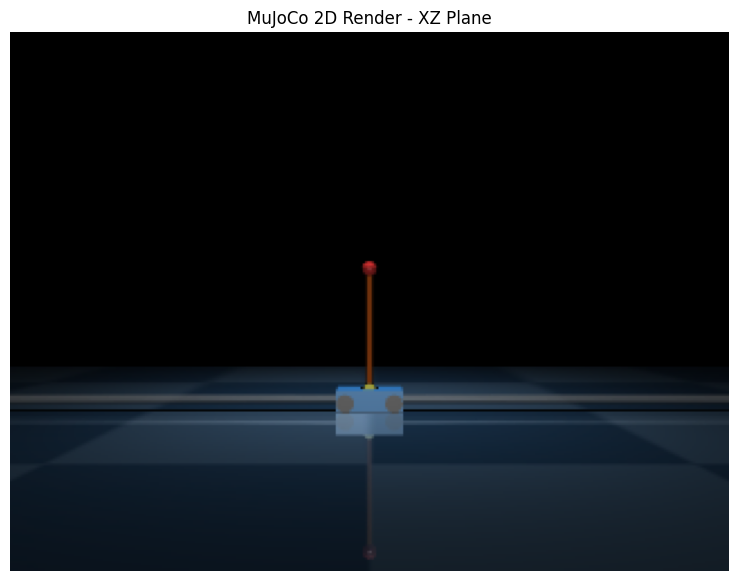

In [76]:
XML_PATH = 'inverted_pendulum_v03/inverted_pendulum_v03.xml'

model = mujoco.MjModel.from_xml_path(XML_PATH)
data = mujoco.MjData(model)

# Make renderer, render and show the pixels
with mujoco.Renderer(model) as renderer:
    mujoco.mj_forward(model, data)
    renderer.update_scene(data, camera="view_2d")
    media.show_image(renderer.render())
with mujoco.Renderer(model) as renderer:
    renderer.update_scene(data, camera="view_2d")
    pixels = renderer.render()

plt.figure(figsize=(10, 7))
plt.imshow(pixels)
plt.axis('off')
plt.title("MuJoCo 2D Render - XZ Plane")
plt.show()

""

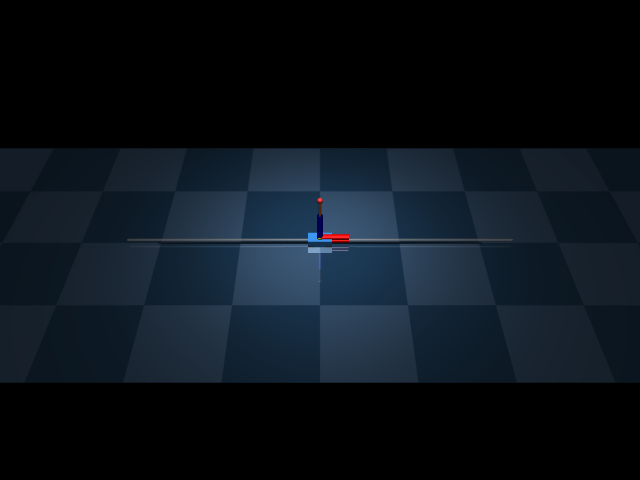

In [ ]:
def make_scene_option(frame=mujoco.mjtFrame.mjFRAME_BODY):
    scene_option = mujoco.MjvOption()
    scene_option.frame = frame
    return scene_option


def render_frame(model, data, width=None, height=None, camera=None, scene_option=None):
    max_width = int(model.vis.global_.offwidth)
    max_height = int(model.vis.global_.offheight)

    width = max_width if width is None else min(int(width), max_width)
    height = max_height if height is None else min(int(height), max_height)

    renderer = mujoco.Renderer(model, width=width, height=height)
    try:
        if camera is None:
            renderer.update_scene(data, scene_option=scene_option)
        else:
            renderer.update_scene(data, camera=camera, scene_option=scene_option)
        return renderer.render()
    finally:
        renderer.close()


scene_option = make_scene_option(frame=mujoco.mjtFrame.mjFRAME_BODY)

mujoco.mj_forward(model, data)
media.show_image(render_frame(model, data, scene_option=scene_option))

## PID Controllers

Phần dưới đây giữ nguyên tinh thần của script gốc:
- PID cơ bản
- anti-windup bằng cách kẹp tích phân
- derivative on measurement để tránh derivative kick
- saturation ở đầu ra

In [ ]:
class PIDController:
    """
    Bộ điều khiển PID cơ bản với:
    - anti-windup bằng cách kẹp tích phân
    - derivative on measurement
    - output saturation
    """

    def __init__(
        self,
        kp,
        ki,
        kd,
        setpoint=0.0,
        output_limits=(-np.inf, np.inf),
        integral_limits=(-np.inf, np.inf),
        dt=0.002,
    ):
        self.kp = kp
        self.ki = ki
        self.kd = kd
        self.setpoint = setpoint
        self.out_min, self.out_max = output_limits
        self.int_min, self.int_max = integral_limits
        self.dt = dt

        self._integral = 0.0
        self._prev_meas = None

    def reset(self):
        self._integral = 0.0
        self._prev_meas = None

    def __call__(self, measurement):
        error = self.setpoint - measurement

        p_term = self.kp * error

        self._integral += error * self.dt
        self._integral = float(np.clip(self._integral, self.int_min, self.int_max))
        i_term = self.ki * self._integral

        if self._prev_meas is None:
            d_term = 0.0
        else:
            d_term = -self.kd * (measurement - self._prev_meas) / self.dt
        self._prev_meas = measurement

        output = float(np.clip(p_term + i_term + d_term, self.out_min, self.out_max))
        return output, p_term, i_term, d_term


class DisturbanceSchedule:
    """
    Danh sách xung lực nhiễu:
    (t_start, duration, magnitude)
    """

    def __init__(self, events):
        self.events = events

    def get(self, t):
        for t0, duration, magnitude in self.events:
            if t0 <= t < t0 + duration:
                return magnitude
        return 0.0

## PID gains and disturbance schedule

Các gain dưới đây được giữ giống script mẫu của bạn để notebook phản ánh đúng cùng một chiến lược điều khiển.

In [ ]:
DT = model.opt.timestep

pid_angle = PIDController(
    kp=-100.0,
    ki=-1.0,
    kd=-15.0,
    setpoint=0.0,
    output_limits=(-30.0, 30.0),
    integral_limits=(-8.0, 8.0),
    dt=DT,
)

pid_position = PIDController(
    kp=0.3,
    ki=0.02,
    kd=0.8,
    setpoint=0.0,
    output_limits=(-0.15, 0.15),
    integral_limits=(-0.2, 0.2),
    dt=DT,
)

disturbances = DisturbanceSchedule([
    (2.0, 0.05, 8.0),
    (5.0, 0.05, -12.0),
    (8.0, 0.10, 10.0),
    (11.0, 0.05, -15.0),
])

print('Angle PID:', pid_angle.kp, pid_angle.ki, pid_angle.kd)
print('Position PID:', pid_position.kp, pid_position.ki, pid_position.kd)

Angle PID: -100.0 -1.0 -15.0
Position PID: 0.3 0.02 0.8


## MuJoCo simulation loop

Hàm dưới đây là bản notebook-friendly của script:
- load MuJoCo model
- đặt trạng thái đầu `theta = initial_theta`
- đọc `x, x_dot, theta, theta_dot` từ `sensordata`
- PID vị trí sinh `theta_ref`
- PID góc sinh lực điều khiển `F_ctrl`
- cộng thêm nhiễu `F_dist`
- truyền tổng lực vào `data.ctrl[0]`
- lưu log và render frame để hiển thị video trong notebook

In [ ]:
def run_simulation(
    xml_path=XML_PATH,
    sim_time=12.0,
    initial_theta=0.05,
    render_every=50,
    width=None,
    height=None,
    camera=None,
    position_controller=None,
    angle_controller=None,
    disturbance_schedule=None,
    scene_option=None,
):
    model = mujoco.MjModel.from_xml_path(xml_path)
    data = mujoco.MjData(model)

    position_controller = position_controller or pid_position
    angle_controller = angle_controller or pid_angle
    disturbance_schedule = disturbance_schedule or disturbances

    data.qpos[0] = 0.0
    data.qpos[1] = initial_theta
    data.qvel[:] = 0.0
    data.ctrl[:] = 0.0
    mujoco.mj_forward(model, data)

    position_controller.reset()
    angle_controller.reset()

    log = {
        't': [],
        'x': [],
        'x_dot': [],
        'theta': [],
        'theta_dot': [],
        'F_ctrl': [],
        'F_disturb': [],
        'F_total': [],
        'theta_ref': [],
        'p_term': [],
        'i_term': [],
        'd_term': [],
    }

    frames = []
    nsteps = int(sim_time / model.opt.timestep)

    for step in range(nsteps):
        t = step * model.opt.timestep

        # Sensor layout from XML:
        # 0: x, 1: x_dot, 2: theta, 3: theta_dot
        x = float(data.sensordata[0])
        x_dot = float(data.sensordata[1])
        theta = float(data.sensordata[2])
        theta_dot = float(data.sensordata[3])

        theta_ref, *_ = position_controller(x)
        angle_controller.setpoint = theta_ref

        F_ctrl, p_term, i_term, d_term = angle_controller(theta)
        F_disturb = float(disturbance_schedule.get(t))
        F_total = float(np.clip(F_ctrl + F_disturb, -30.0, 30.0))

        data.ctrl[0] = F_total
        mujoco.mj_step(model, data)

        if step % render_every == 0:
            frames.append(render_frame(model, data, width=width, height=height, camera=camera, scene_option=scene_option))

        log['t'].append(t)
        log['x'].append(x)
        log['x_dot'].append(x_dot)
        log['theta'].append(np.degrees(theta))
        log['theta_dot'].append(np.degrees(theta_dot))
        log['F_ctrl'].append(F_ctrl)
        log['F_disturb'].append(F_disturb)
        log['F_total'].append(F_total)
        log['theta_ref'].append(np.degrees(theta_ref))
        log['p_term'].append(p_term)
        log['i_term'].append(i_term)
        log['d_term'].append(d_term)

    return {key: np.array(value) for key, value in log.items()}, frames

In [ ]:
def plot_results(log, save_path=None):
    t = log['t']
    dist_mask = log['F_disturb'] != 0

    fig = plt.figure(figsize=(14, 10), facecolor='#0d1117')
    fig.suptitle('Inverted Pendulum - PID Controller (MuJoCo)', color='white', fontsize=14, fontweight='bold', y=0.98)

    gs = gridspec.GridSpec(3, 2, hspace=0.55, wspace=0.38, left=0.07, right=0.97, top=0.93, bottom=0.07)

    DARK = '#0d1117'
    AXES = '#161b22'
    GRID = '#21262d'
    WHITE = '#e6edf3'
    BLUE = '#58a6ff'
    ORANGE = '#f78166'
    GREEN = '#3fb950'
    YELL = '#d29922'
    PURPLE = '#bc8cff'

    def styled_ax(ax, title, ylabel, xlabel='time [s]'):
        ax.set_facecolor(AXES)
        ax.set_title(title, color=WHITE, fontsize=10, pad=6)
        ax.set_ylabel(ylabel, color=WHITE, fontsize=8)
        ax.set_xlabel(xlabel, color=WHITE, fontsize=8)
        ax.tick_params(colors=WHITE, labelsize=7)
        for spine in ax.spines.values():
            spine.set_edgecolor(GRID)
        ax.grid(color=GRID, linewidth=0.6, linestyle='--', alpha=0.7)
        ax.set_xlim(t[0], t[-1])

    def mark_disturbances(ax):
        for t_dist in t[dist_mask]:
            ax.axvline(t_dist, color=ORANGE, alpha=0.25, linewidth=1.0)

    ax1 = fig.add_subplot(gs[0, 0])
    styled_ax(ax1, 'Pendulum angle', 'theta [deg]')
    ax1.plot(t, log['theta'], color=BLUE, lw=1.5, label='theta')
    ax1.plot(t, log['theta_ref'], color=GREEN, lw=1.0, linestyle='--', label='theta_ref')
    ax1.axhline(0, color=WHITE, lw=0.5, alpha=0.4)
    mark_disturbances(ax1)
    ax1.legend(fontsize=7, facecolor=AXES, labelcolor=WHITE, framealpha=0.7, loc='upper right')

    ax2 = fig.add_subplot(gs[0, 1])
    styled_ax(ax2, 'Cart position', 'x [m]')
    ax2.plot(t, log['x'], color=PURPLE, lw=1.5, label='x')
    ax2.axhline(0, color=WHITE, lw=0.5, alpha=0.4, linestyle='--', label='x_ref = 0')
    mark_disturbances(ax2)
    ax2.legend(fontsize=7, facecolor=AXES, labelcolor=WHITE, framealpha=0.7, loc='upper right')

    ax3 = fig.add_subplot(gs[1, 0])
    styled_ax(ax3, 'Applied force', 'F [N]')
    ax3.plot(t, log['F_ctrl'], color=GREEN, lw=1.5, label='F_pid')
    ax3.plot(t, log['F_disturb'], color=ORANGE, lw=2.0, linestyle=':', label='F_disturb')
    ax3.plot(t, log['F_total'], color=BLUE, lw=1.0, alpha=0.9, label='F_total')
    ax3.axhline(0, color=WHITE, lw=0.5, alpha=0.4)
    ax3.legend(fontsize=7, facecolor=AXES, labelcolor=WHITE, framealpha=0.7, loc='upper right')

    ax4 = fig.add_subplot(gs[1, 1])
    styled_ax(ax4, 'Angle PID terms', 'force contribution [N]')
    ax4.plot(t, log['p_term'], color=BLUE, lw=1.2, label='P')
    ax4.plot(t, log['i_term'], color=GREEN, lw=1.2, label='I')
    ax4.plot(t, log['d_term'], color=YELL, lw=1.2, label='D')
    ax4.axhline(0, color=WHITE, lw=0.5, alpha=0.4)
    ax4.legend(fontsize=7, facecolor=AXES, labelcolor=WHITE, framealpha=0.7, loc='upper right')

    ax5 = fig.add_subplot(gs[2, :])
    styled_ax(ax5, 'Phase portrait', 'theta_dot [deg/s]', xlabel='theta [deg]')
    sc = ax5.scatter(log['theta'], log['theta_dot'], c=t, cmap='plasma', s=1, alpha=0.6)
    ax5.axhline(0, color=WHITE, lw=0.4, alpha=0.3)
    ax5.axvline(0, color=WHITE, lw=0.4, alpha=0.3)
    cbar = plt.colorbar(sc, ax=ax5, pad=0.01)
    cbar.set_label('time [s]', color=WHITE, fontsize=8)
    cbar.ax.yaxis.set_tick_params(color=WHITE, labelsize=7)
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color=WHITE)
    cbar.outline.set_edgecolor(GRID)

    fig.patch.set_facecolor(DARK)

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=DARK)
        print('Saved:', save_path)
    else:
        plt.show()

    return fig

## Run MuJoCo + cascade PID

Cell này chạy đúng mô hình MuJoCo với disturbance schedule. Vì notebook dùng offscreen render, kết quả được hiển thị bằng video và biểu đồ.

In [ ]:
log, frames = run_simulation(
    xml_path=XML_PATH,
    sim_time=50.0,
    initial_theta=0.05,
    render_every=50,
    scene_option=scene_option,
)

print('theta max [deg] =', float(np.max(log['theta'])))
print('theta RMS [deg] =', float(np.sqrt(np.mean(log['theta'] ** 2))))
print('x max [m] =', float(np.max(log['x'])))
print('F max [N] =', float(np.max(log['F_total'])))

theta max [deg] = 6.473094943912665
theta RMS [deg] = 3.1403613145299594
x max [m] = 2.431564856828646
F max [N] = 30.0


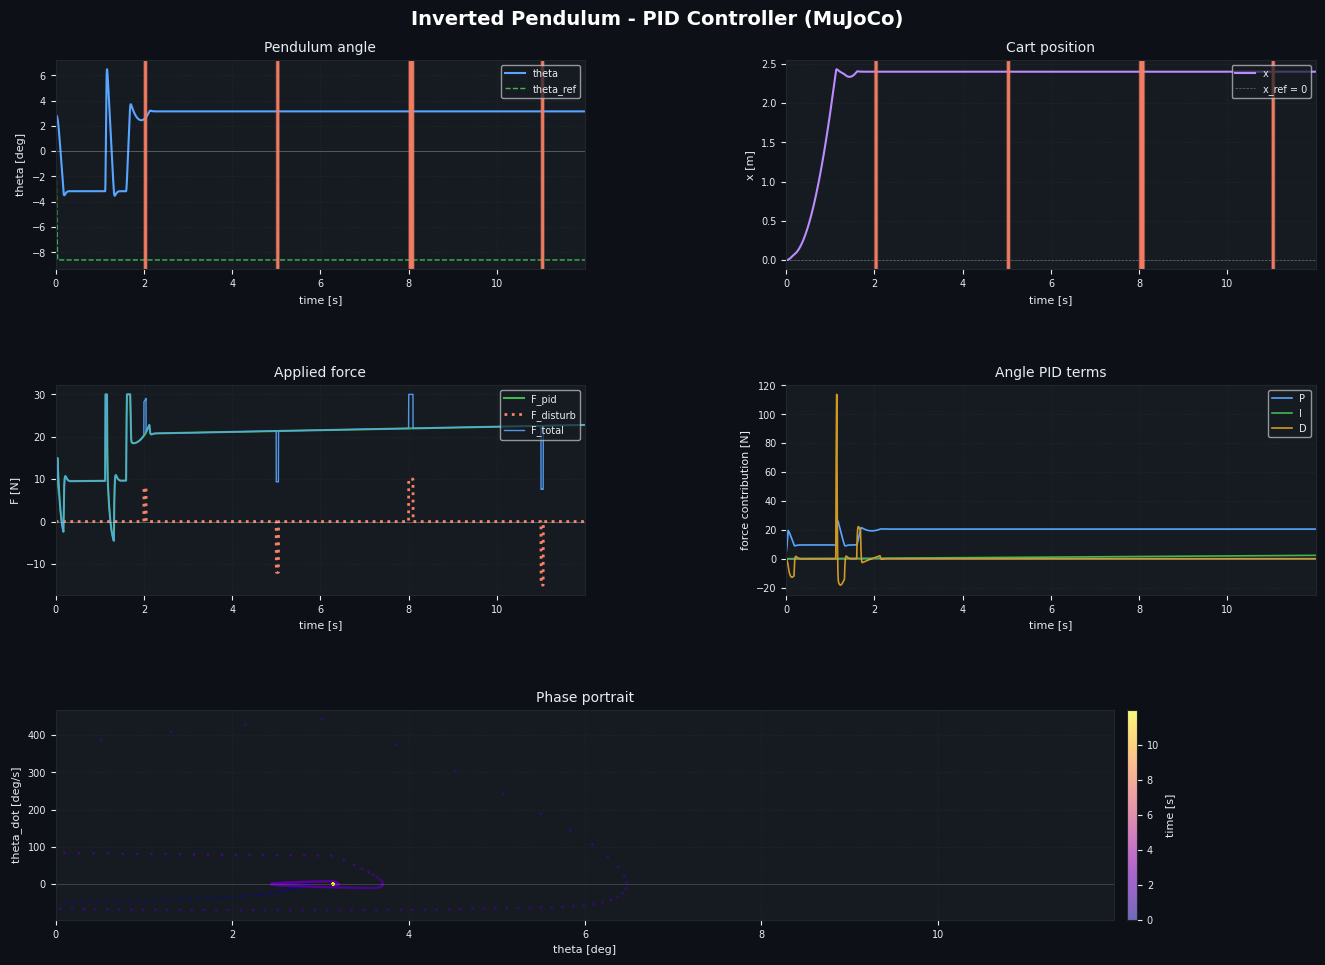

This browser does not support the video tag.


In [ ]:
plot_results(log)
media.show_video(frames, fps=int(round(1.0 / (model.opt.timestep * 50))))

## Analytical fallback model

Phần này cũng được giữ lại từ script để kiểm tra nhanh logic PID trên mô hình động lực học cart-pole viết tay.
Nó không thay MuJoCo, nhưng hữu ích để sanity-check gain và so sánh xu hướng.

In [ ]:
def run_analytical_simulation(sim_time=12.0, initial_theta=0.05):
    M = 1.0
    m = 0.4
    l = 0.6
    g = 9.81
    dt = DT
    nsteps = int(sim_time / dt)

    state = np.array([0.0, 0.0, initial_theta, 0.0], dtype=float)

    pid_angle.reset()
    pid_position.reset()

    log = {
        't': [],
        'x': [],
        'x_dot': [],
        'theta': [],
        'theta_dot': [],
        'F_ctrl': [],
        'F_disturb': [],
        'F_total': [],
        'theta_ref': [],
        'p_term': [],
        'i_term': [],
        'd_term': [],
    }

    for step in range(nsteps):
        t = step * dt
        x, x_dot, theta, theta_dot = state

        theta_ref, *_ = pid_position(x)
        pid_angle.setpoint = theta_ref
        F_ctrl, p_term, i_term, d_term = pid_angle(theta)
        F_disturb = float(disturbances.get(t))
        F_total = float(np.clip(F_ctrl + F_disturb, -30.0, 30.0))

        sin_t = np.sin(theta)
        cos_t = np.cos(theta)
        denom = M + m - m * cos_t ** 2

        theta_ddot = ((M + m) * g * sin_t - cos_t * (F_total + m * l * theta_dot ** 2 * sin_t)) / (l * denom)
        x_ddot = (F_total + m * l * (theta_dot ** 2 * sin_t - theta_ddot * cos_t)) / (M + m)

        state[1] += x_ddot * dt
        state[3] += theta_ddot * dt
        state[0] += state[1] * dt
        state[2] += state[3] * dt
        state[0] = float(np.clip(state[0], -2.4, 2.4))

        log['t'].append(t)
        log['x'].append(state[0])
        log['x_dot'].append(state[1])
        log['theta'].append(np.degrees(state[2]))
        log['theta_dot'].append(np.degrees(state[3]))
        log['F_ctrl'].append(F_ctrl)
        log['F_disturb'].append(F_disturb)
        log['F_total'].append(F_total)
        log['theta_ref'].append(np.degrees(theta_ref))
        log['p_term'].append(p_term)
        log['i_term'].append(i_term)
        log['d_term'].append(d_term)

    return {key: np.array(value) for key, value in log.items()}

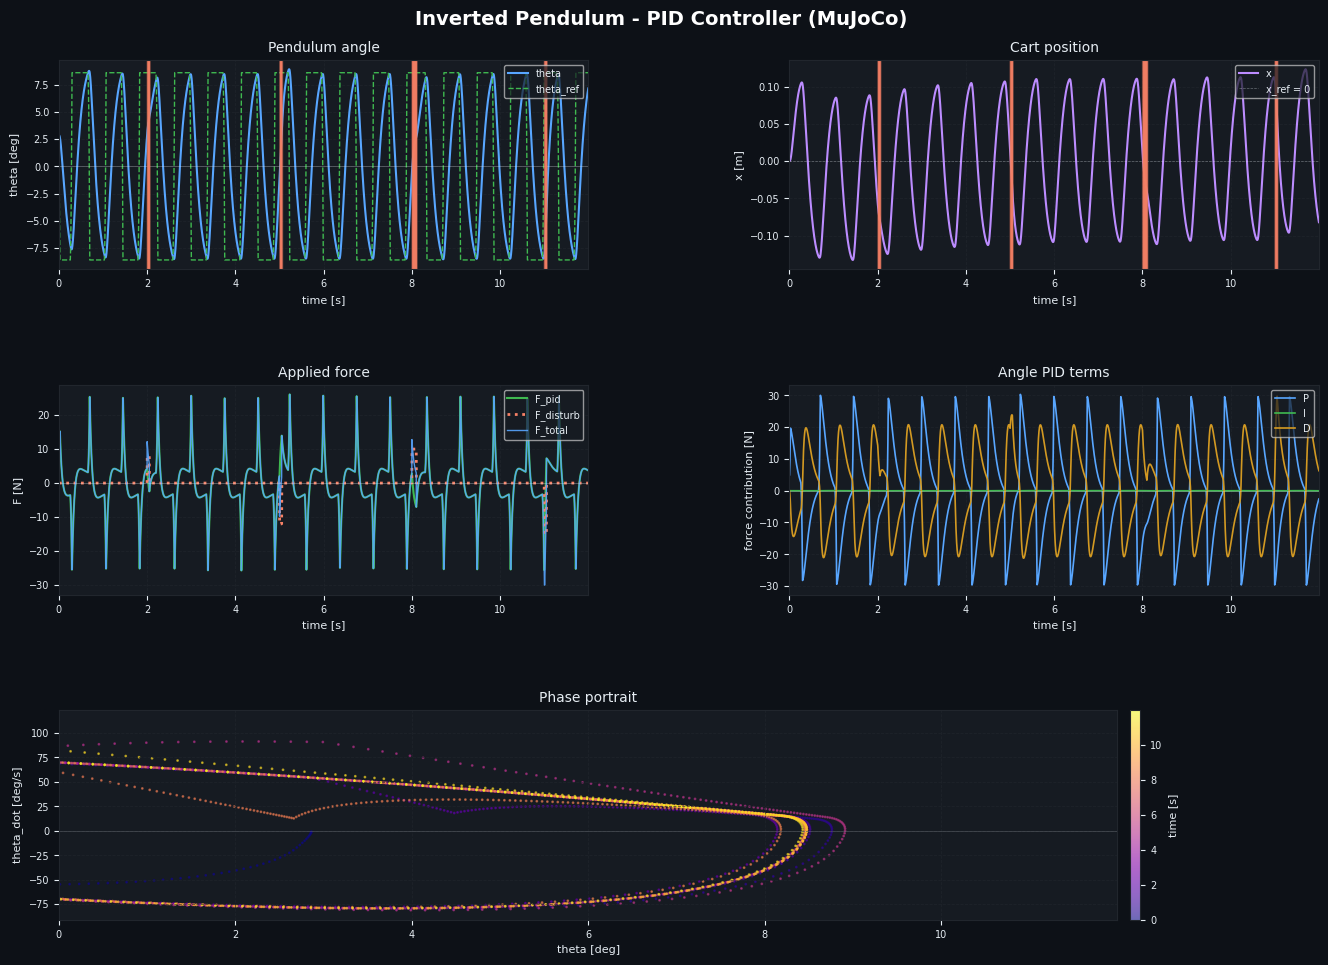

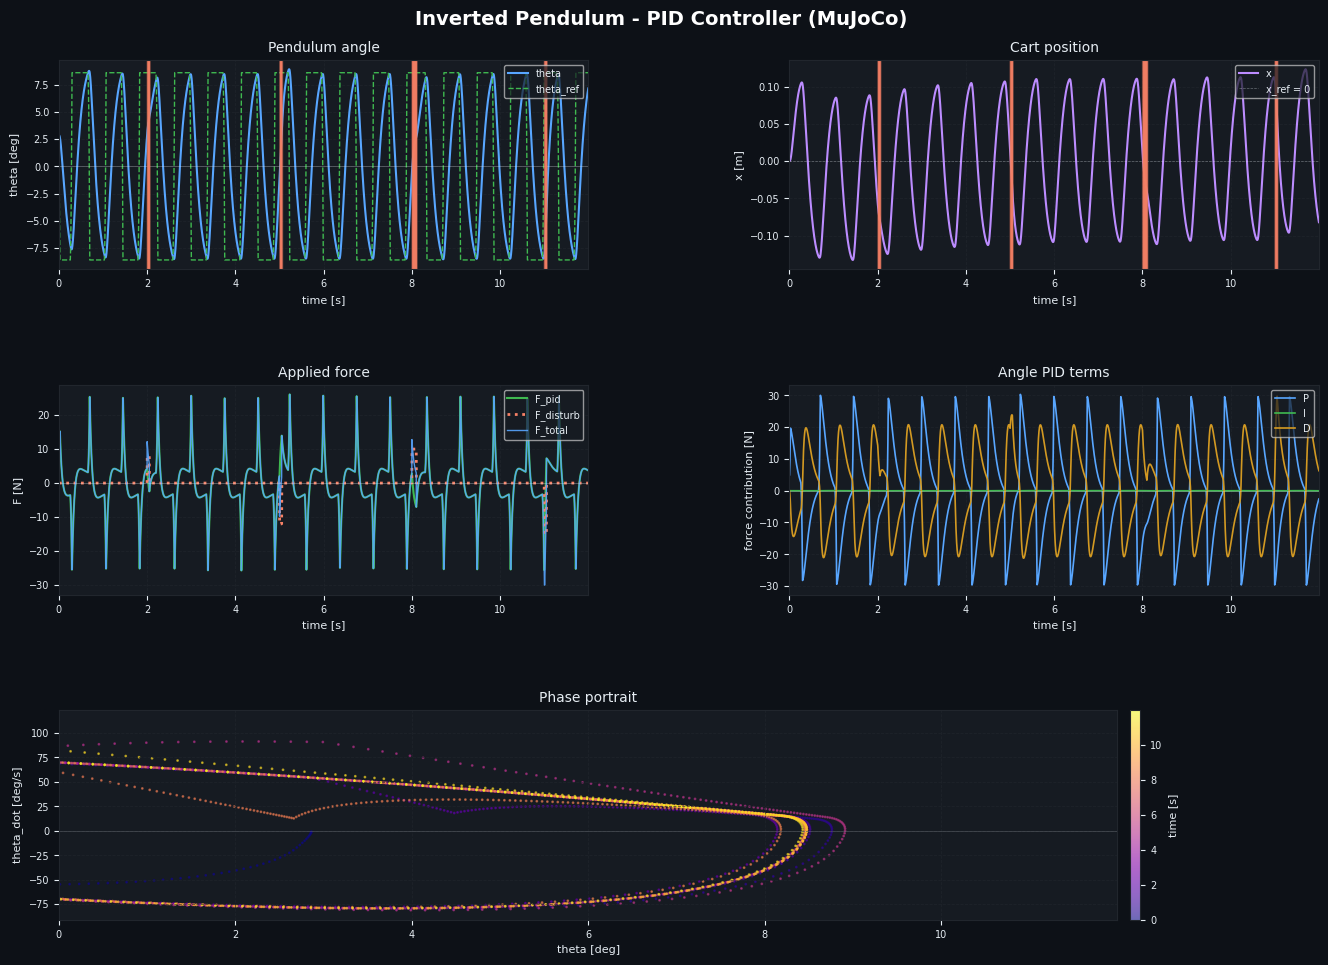

In [ ]:
analytical_log = run_analytical_simulation(sim_time=12.0, initial_theta=0.05)
plot_results(analytical_log)

## Notes

- Notebook này bám theo đúng mô hình script PID cascade bạn đưa, nhưng đã đổi sang dạng phù hợp với Jupyter.
- XML đang dùng là [inverted_pendulum_v03.xml](inverted_pendulum_v03/inverted_pendulum_v03.xml).
- MuJoCo đọc trạng thái qua `sensordata`, nên code rất gần với cấu trúc bộ điều khiển thời gian thực.
- Vòng ngoài sinh `theta_ref`, vòng trong sinh `F`.
- Nếu sau này bạn muốn nâng cấp, bước tiếp theo hợp lý là so sánh PID cascade này với LQR hoặc MPC ngay trên cùng XML.